In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("financial_regression.csv")

In [3]:

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.drop(columns=['date'])

In [4]:
df = df.fillna(df.mean())

In [5]:
X = df.drop(columns=['sp500 close'])
y = df['sp500 close']

In [6]:
X = X.select_dtypes(include=['int64', 'float64'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [10]:
y_pred_svr = svr_model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print("SVR MAE :", mae)
print("SVR MSE :", mse)
print("SVR RMSE:", rmse)
print("SVR R2 Score:", r2)

SVR MAE : 8.34630564091144
SVR MSE : 457.58547817132774
SVR RMSE: 21.391247700200374
SVR R2 Score: 0.9674915733406672


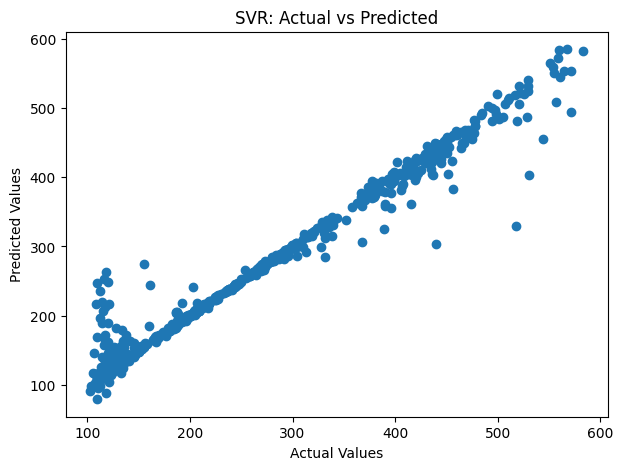

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted")
plt.show()

In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression"],
    "R2 Score": [0.9674915733406672, r2]
})

results

,Model,R2 Score
0,Linear Regression,0.967492
1,Support Vector Regression,0.967492


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'C': [10, 50, 100, 200],
    'gamma': [0.01, 0.05, 0.1],
    'epsilon': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [10, 50, ...], 'epsilon': [0.01, 0.05, ...], 'gamma': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [15]:
print("Best Parameters:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Parameters: {'C': 200, 'epsilon': 0.01, 'gamma': 0.01}
Best R2 Score: 0.9974445952782002


In [16]:
best_svr = grid.best_estimator_

y_pred_best = best_svr.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("Optimized SVR MAE :", mae)
print("Optimized SVR RMSE:", rmse)
print("Optimized SVR R2  :", r2)


Optimized SVR MAE : 1.3513216439808886
Optimized SVR RMSE: 3.0400663113229665
Optimized SVR R2  : 0.9993434167017858


In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_svr, X, y, cv=10, scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross-Validation R2 Scores: [-24.15743986 -20.42193427 -15.79092418 -20.26824828  -8.24506425
  -0.04415385  -1.53167117  -6.17614302 -13.28977211 -12.00629187]
Average CV R2: -12.193164285960204


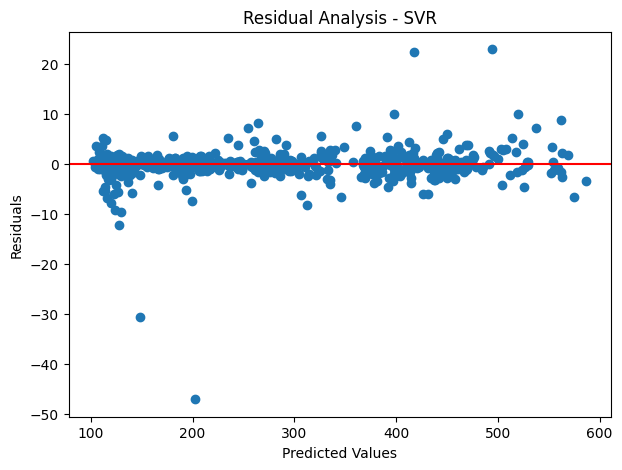

In [19]:
residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))
plt.scatter(y_pred_best, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis - SVR")
plt.show()


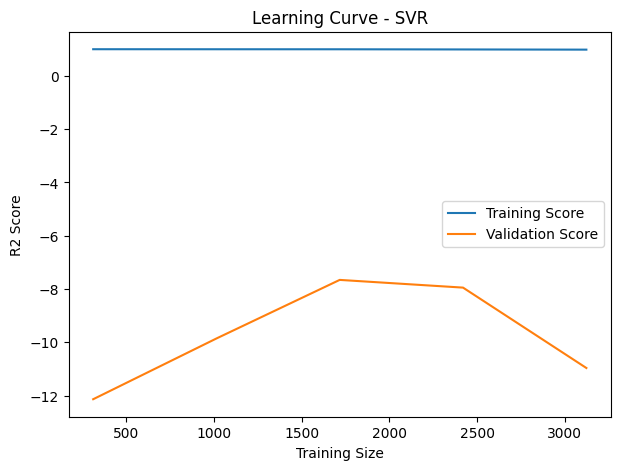

In [20]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_svr, X, y, cv=5, scoring='r2'
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()
plt.title("Learning Curve - SVR")
plt.show()


In [21]:
import joblib

joblib.dump(best_svr, "svr_financial_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:
feature_names = X.columns.tolist()
print(len(feature_names))
feature_names

45


['sp500 open',
 'sp500 high',
 'sp500 low',
 'sp500 volume',
 'sp500 high-low',
 'nasdaq open',
 'nasdaq high',
 'nasdaq low',
 'nasdaq close',
 'nasdaq volume',
 'nasdaq high-low',
 'us_rates_%',
 'CPI',
 'usd_chf',
 'eur_usd',
 'GDP',
 'silver open',
 'silver high',
 'silver low',
 'silver close',
 'silver volume',
 'silver high-low',
 'oil open',
 'oil high',
 'oil low',
 'oil close',
 'oil volume',
 'oil high-low',
 'platinum open',
 'platinum high',
 'platinum low',
 'platinum close',
 'platinum volume',
 'platinum high-low',
 'palladium open',
 'palladium high',
 'palladium low',
 'palladium close',
 'palladium volume',
 'palladium high-low',
 'gold open',
 'gold high',
 'gold low',
 'gold close',
 'gold volume']